In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [3]:
df = pd.read_csv("/content/StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df["Average"] = (df["math score"] +
                 df["reading score"] +
                 df["writing score"]) / 3

In [7]:
def grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 60:
        return "B"
    else:
        return "C"

df["Grade"] = df["Average"].apply(grade)

In [8]:
X = df[["math score", "reading score", "writing score"]]
y = df["Grade"]

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", random_state=42)

model.fit(X_train, y_train)

SVC(random_state=42)

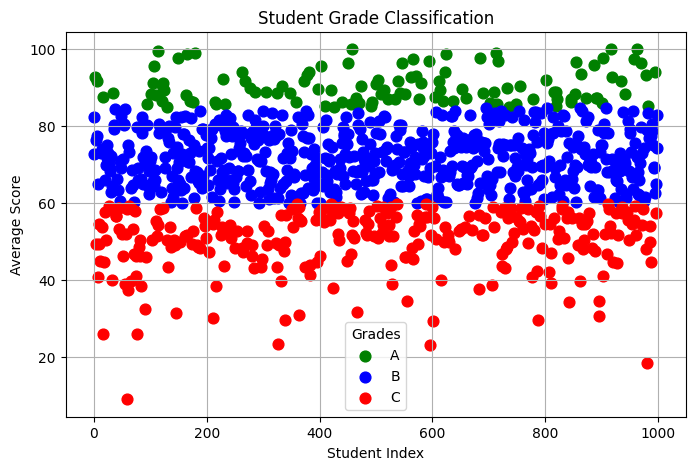

In [19]:
import matplotlib.pyplot as plt

colors = {
    "A": "green",
    "B": "blue",
    "C": "red"
}

plt.figure(figsize=(8,5))

for grade in colors:
    data = df[df["Grade"] == grade]
    plt.scatter(
        data.index,
        data["Average"],
        color=colors[grade],
        label=grade,
        s=60
    )

plt.title("Student Grade Classification")
plt.xlabel("Student Index")
plt.ylabel("Average Score")
plt.legend(title="Grades")
plt.grid(True)

plt.show()

Enter Math Score: 78
Enter Reading Score: 95
Enter Writing Score: 86
Predicted Grade: A


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


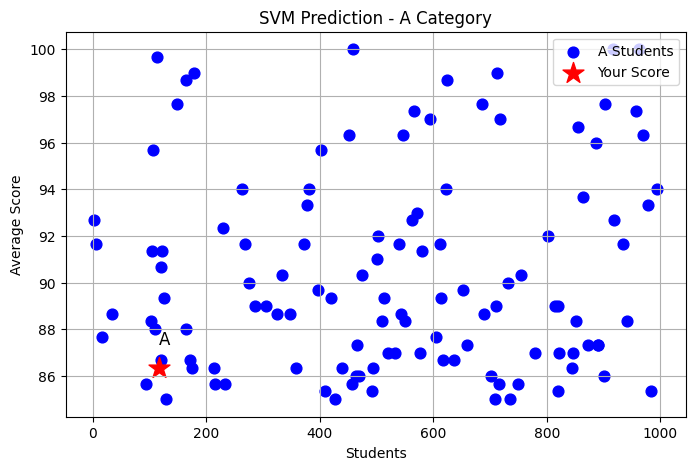

In [23]:
math = float(input("Enter Math Score: "))
reading = float(input("Enter Reading Score: "))
writing = float(input("Enter Writing Score: "))

new_student = [[math, reading, writing]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)
predicted_grade = le.inverse_transform(prediction)[0]

print("Predicted Grade:", predicted_grade)

average = (math + reading + writing) / 3

filtered_df = df[df["Grade"] == predicted_grade]

plt.figure(figsize=(8,5))

plt.scatter(
    filtered_df.index,
    filtered_df["Average"],
    color="blue",
    s=60,
    label=f"{predicted_grade} Students"
)

plt.scatter(
    len(filtered_df),
    average,
    color="red",
    marker="*",
    s=250,
    label="Your Score"
)

plt.text(
    len(filtered_df),
    average + 1,
    predicted_grade,
    fontsize=12
)

plt.title(f"SVM Prediction - {predicted_grade} Category")
plt.xlabel("Students")
plt.ylabel("Average Score")
plt.legend(loc="upper right")
plt.grid(True)

plt.show()